## 1. Import Library & Deklarasi Variabel Global

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

INPUT_WIDTH = 120
LABEL_WIDTH = 24
NUM_FEATURES = 4
HIDDEN_DIM = 64

## 2. Data Loading & Pemilihan Fitur

In [2]:
df = pd.read_csv('Bitcoin3.csv', parse_dates=['Date'], index_col='Date')

features = ['Close', 'Volume USDT', 'RSI']
df = df[features].copy()

## 3. Exploratory Data Analysis (EDA)
### 3.1 Matriks Korelasi Fitur

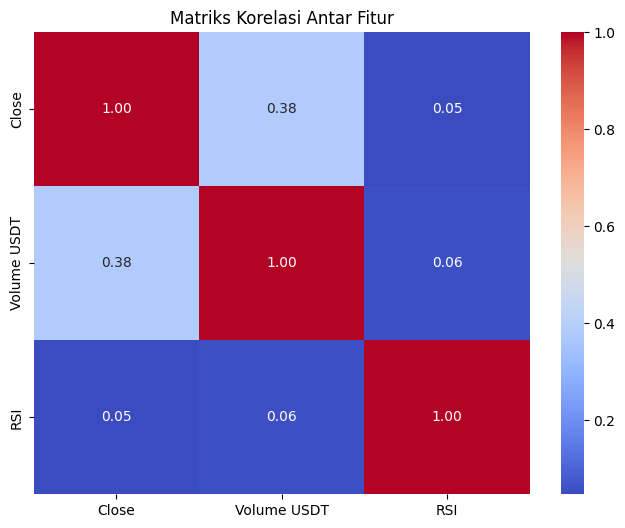

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi Antar Fitur')
plt.show()

### 3.2 Time Series Decomposition

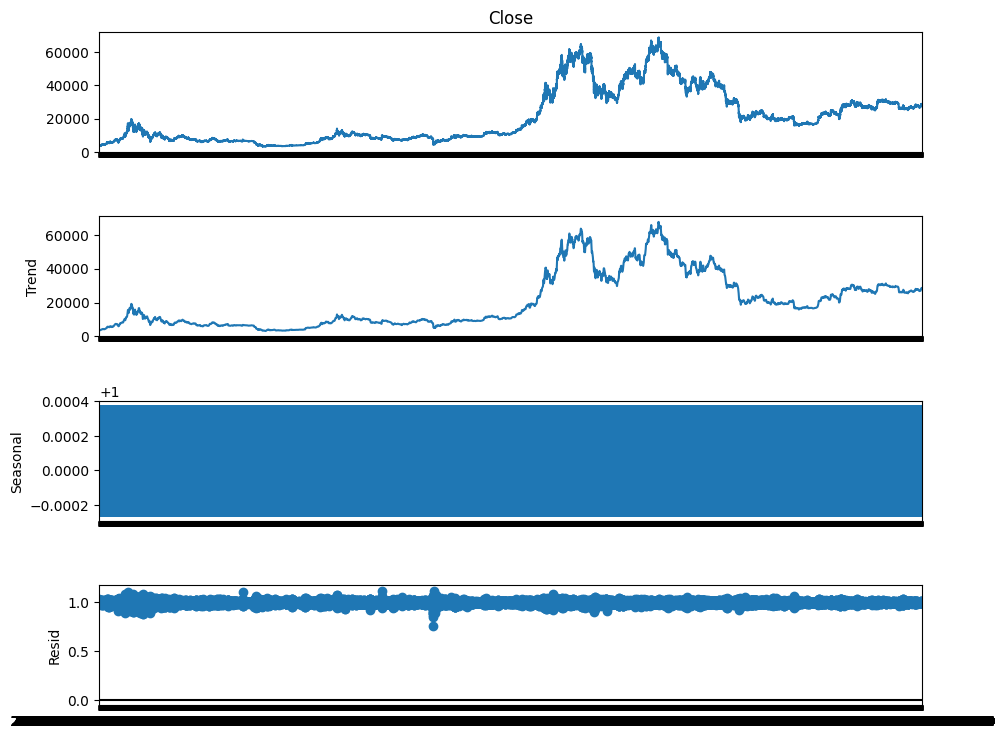

In [4]:
# Interpolasi untuk mengatasi kemungkinan nilai NaN pada deret waktu
df_clean = df.interpolate(method='linear')
decomposition = seasonal_decompose(df_clean['Close'], model='multiplicative', period=24)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

### 3.3 Uji Autokorelasi (ACF & PACF)

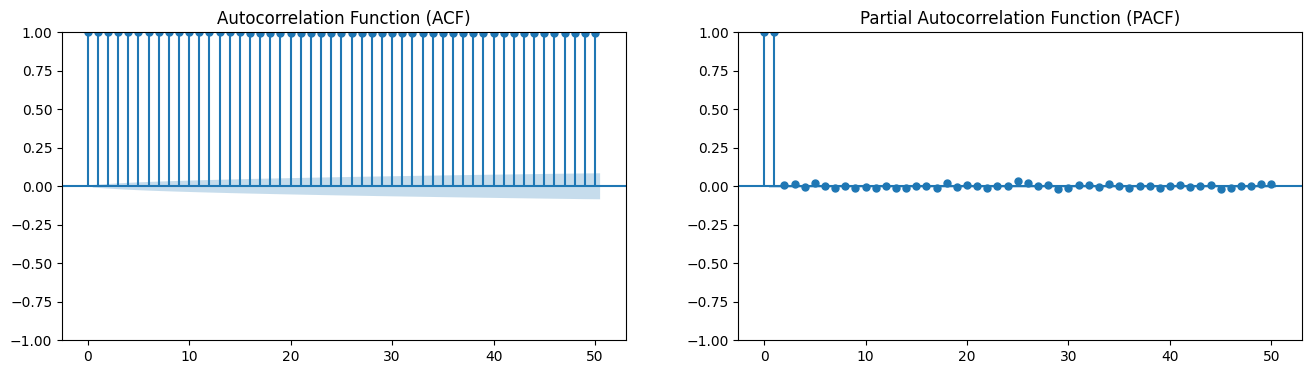

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(df_clean['Close'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df_clean['Close'], lags=50, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.show()

## 4. Feature Engineering

In [6]:
# Menambahkan konteks tren jangka pendek (rata-rata 24 jam terakhir)
df['Rolling_Mean_24'] = df['Close'].rolling(window=24).mean()
df.dropna(inplace=True)

## 5. Splitting & Scaling Data

In [7]:
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.2)

# Memecah data secara sekuensial untuk mencegah data leakage
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size : train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Proporsi Split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

# Fitting scaler hanya pada data train
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

Proporsi Split: Train=37188, Val=10625, Test=5314


## 6. Pipeline tf.data.Dataset

In [8]:
def create_multistep_dataset(data, input_width, label_width, target_col_idx, batch_size=32):
    X, y = [], []

    for i in range(len(data) - input_width - label_width + 1):
        X.append(data[i : i + input_width, :])
        y.append(data[i + input_width : i + input_width + label_width, target_col_idx])

    X_arr = np.array(X, dtype=np.float32)
    y_arr = np.array(y, dtype=np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((X_arr, y_arr))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

### 6.1 Pembuatan Dataset & Verifikasi Dimensi

In [9]:
target_idx = df.columns.get_loc('Close') 

train_ds = create_multistep_dataset(train_scaled, INPUT_WIDTH, LABEL_WIDTH, target_idx)
val_ds = create_multistep_dataset(val_scaled, INPUT_WIDTH, LABEL_WIDTH, target_idx)
test_ds = create_multistep_dataset(test_scaled, INPUT_WIDTH, LABEL_WIDTH, target_idx)

# Verifikasi bentuk tensor dari batch pertama
for X_batch, y_batch in train_ds.take(1):
    print(f"\nBentuk Tensor Input (X): {X_batch.shape}")
    print(f"Bentuk Tensor Label (y): {y_batch.shape}")


Bentuk Tensor Input (X): (32, 120, 4)
Bentuk Tensor Label (y): (32, 24)


## 7. Pengaturan Seed & Reproducibility

In [10]:
# Mengunci Seed agar hasil training konsisten (Reproducible)
tf.random.set_seed(42)
np.random.seed(42)

## 8. Custom Layers
### 8.1 Custom Multi-Head Attention Layer

In [11]:
from tensorflow.keras.layers import Input, LSTM, Dense, Layer, Concatenate, GlobalAveragePooling1D
from tensorflow.keras.models import Model

class CustomMultiHeadAttention(Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.d_model = num_heads * key_dim 
        self.wq = Dense(self.d_model)
        self.wk = Dense(self.d_model)
        self.wv = Dense(self.d_model)
        self.dense_out = Dense(self.d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, query, key, value):
        batch_size = tf.shape(query)[0]
        q = self.split_heads(self.wq(query), batch_size) 
        k = self.split_heads(self.wk(key), batch_size) 
        v = self.split_heads(self.wv(value), batch_size) 

        matmul_qk = tf.matmul(q, k, transpose_b=True) 
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v) 

        output = tf.transpose(output, perm=[0, 2, 1, 3]) 
        concat_attention = tf.reshape(output, (batch_size, -1, self.d_model)) 
        return self.dense_out(concat_attention)

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "key_dim": self.key_dim})
        return config

### 8.2 Custom Dense Layer

In [12]:
class CustomDenseLayer(Layer):
    def __init__(self, units, activation=None, **kwargs):
        super(CustomDenseLayer, self).__init__(**kwargs)
        self.units = units
        self.activation_name = activation # Simpan nama aktivasi sebagai string
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer='random_normal', trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)

    def call(self, inputs):
        linear_op = tf.matmul(inputs, self.w) + self.b
        return self.activation(linear_op) if self.activation is not None else linear_op

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "activation": self.activation_name})
        return config

## 9. Arsitektur Model Seq2Seq (OOP Subclassing)
### 9.1 Custom Encoder

In [13]:
class CustomEncoder(Model):
    def __init__(self, hidden_dim, **kwargs):
        super(CustomEncoder, self).__init__(**kwargs)
        self.hidden_dim = hidden_dim # Simpan argumen
        self.lstm = LSTM(hidden_dim, return_sequences=True, return_state=True, name='enc_lstm')

    def call(self, inputs, training=False):
        enc_output, state_h, state_c = self.lstm(inputs, training=training)
        return enc_output, state_h, state_c

    def get_config(self):
        config = super().get_config()
        config.update({"hidden_dim": self.hidden_dim})
        return config

### 9.2 Custom Decoder

In [14]:
class CustomDecoder(Model):
    def __init__(self, hidden_dim, **kwargs):
        super(CustomDecoder, self).__init__(**kwargs)
        self.hidden_dim = hidden_dim # Simpan argumen
        self.lstm = LSTM(hidden_dim, return_sequences=True, return_state=True, name='dec_lstm')
        self.mha = CustomMultiHeadAttention(num_heads=4, key_dim=16, name='dec_mha')
        self.concat = Concatenate(name='dec_concat')
        self.dense = Dense(1, activation='linear', name='dec_dense')

    def call(self, inputs, training=False):
        dec_input, enc_output, state_h, state_c = inputs
        lstm_out, h, c = self.lstm(dec_input, initial_state=[state_h, state_c], training=training)
        context_vector = self.mha(query=lstm_out, key=enc_output, value=enc_output)
        concat_out = self.concat([context_vector, lstm_out])
        final_output = self.dense(concat_out)
        return final_output, h, c

    def get_config(self):
        config = super().get_config()
        config.update({"hidden_dim": self.hidden_dim})
        return config

### 9.3 Inisialisasi Objek Model Seq2Seq

In [15]:
encoder = CustomEncoder(hidden_dim=HIDDEN_DIM, name="OOP_Encoder")
decoder = CustomDecoder(hidden_dim=HIDDEN_DIM, name="OOP_Decoder")

## 10. Arsitektur Model Baseline MHA
### 10.1 Fungsi Build Baseline

In [16]:
def build_baseline_mha(input_width, num_features, label_width):
    inputs = Input(shape=(input_width, num_features), name='baseline_input')
    lstm_out = LSTM(64, return_sequences=True, activation='tanh')(inputs)
    mha_layer = CustomMultiHeadAttention(num_heads=4, key_dim=16)
    attn_out = mha_layer(query=lstm_out, key=lstm_out, value=lstm_out)
    pooled_out = GlobalAveragePooling1D()(attn_out)
    outputs = CustomDenseLayer(label_width, activation='linear')(pooled_out)
    
    model = Model(inputs=inputs, outputs=outputs, name="Baseline_MHA")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

### 10.2 Inisialisasi Model Baseline

In [17]:
baseline_mha_model = build_baseline_mha(INPUT_WIDTH, NUM_FEATURES, LABEL_WIDTH)
print("[*] Arsitektur berhasil dibangun dan siap disimpan ke .keras!")


[*] Arsitektur berhasil dibangun dan siap disimpan ke .keras!


## 11. Pelatihan Model Baseline MHA (Kriteria 1 - Basic)
Pelatihan model baseline menggunakan metode `.fit()` bawaan Keras dengan `EarlyStopping` untuk efisiensi komputasi.

In [18]:
print("[*] Melatih Model Baseline MHA dengan model.fit()...")
# Gunakan EarlyStopping bawaan Keras agar efisien
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_baseline = baseline_mha_model.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=30, 
    callbacks=[early_stopping]
)

[*] Melatih Model Baseline MHA dengan model.fit()...
Epoch 1/30
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0010 - mae: 0.0176 - val_loss: 0.1009 - val_mae: 0.2893
Epoch 2/30
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0022 - mae: 0.0231 - val_loss: 0.1626 - val_mae: 0.3692
Epoch 3/30
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0027 - mae: 0.0257 - val_loss: 0.1524 - val_mae: 0.3513
Epoch 4/30
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0028 - mae: 0.0251 - val_loss: 0.1725 - val_mae: 0.3762
Epoch 5/30
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0029 - mae: 0.0256 - val_loss: 0.1807 - val_mae: 0.3825
Epoch 6/30
1158/1158 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0033 - mae: 0.0285 - val_loss: 0.1275 - val_mae: 0.3153


## 12. Custom Training Components
### 12.1 Custom Loss Function (Weighted MAE)
Memberikan penalti (bobot) yang lebih besar pada kesalahan prediksi di ujung horizon (jam ke-24).

In [19]:
def custom_weighted_mae(y_true, y_pred):
    label_width = tf.shape(y_true)[1]
    weights = tf.reshape(tf.linspace(1.0, 2.0, label_width), (1, -1, 1))
    return tf.reduce_mean(tf.abs(y_true - y_pred) * tf.cast(weights, dtype=tf.float32))

### 12.2 Scheduled Sampling Decay Function
Fungsi untuk menurunkan rasio *Teacher Forcing* secara bertahap seiring berjalannya epoch.

In [20]:
def decay_teacher_forcing_ratio(epoch, max_epochs, start_ratio=1.0, end_ratio=0.0):
    decay_rate = (start_ratio - end_ratio) / max_epochs
    return max(end_ratio, start_ratio - (decay_rate * epoch))

### 12.3 Fungsi Train Step (GradientTape)
Fungsi komputasi graf statis (`@tf.function`) untuk melakukan *forward pass*, menghitung gradien, dan *backpropagation* pada fase latih.

In [32]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

@tf.function
def train_step_attention(x_batch, y_batch, tf_ratio):
    loss = 0.0
    with tf.GradientTape() as tape:
        # 1. Jalankan Encoder
        enc_output, dec_h, dec_c = encoder(x_batch, training=True)

        batch_size = tf.shape(x_batch)[0]
        label_width = tf.shape(y_batch)[1]

        dec_input = tf.zeros((batch_size, 1, 1))
        predictions = tf.TensorArray(tf.float32, size=label_width)

        # 2. Iterasi per jam
        for t in tf.range(label_width):
            dec_pred, dec_h, dec_c = decoder([dec_input, enc_output, dec_h, dec_c], training=True)
            predictions = predictions.write(t, dec_pred[:, 0, :])

            # Scheduled Sampling
            use_teacher_forcing = tf.random.uniform(()) < tf_ratio
            if use_teacher_forcing:
                dec_input = tf.reshape(y_batch[:, t], (batch_size, 1, 1)) # Panduan Asli
            else:
                dec_input = tf.reshape(dec_pred, (batch_size, 1, 1))      # Mandiri

        predictions = tf.transpose(predictions.stack(), [1, 0, 2])
        y_batch_expanded = tf.expand_dims(y_batch, -1)

        loss = custom_weighted_mae(y_batch_expanded, predictions)

    # Backpropagation gabungan
    trainable_vars = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_vars)
    optimizer.apply_gradients(zip(gradients, trainable_vars))
    return loss

### 12.4 Fungsi Validation Step
Fungsi evaluasi model pada data validasi secara *Autoregresif* penuh (tanpa bantuan *Teacher Forcing*).

In [22]:
@tf.function
def val_step_attention(x_batch, y_batch):
    enc_output, dec_h, dec_c = encoder(x_batch, training=False)
    batch_size = tf.shape(x_batch)[0]
    label_width = tf.shape(y_batch)[1]

    dec_input = tf.zeros((batch_size, 1, 1))
    predictions = tf.TensorArray(tf.float32, size=label_width)

    for t in tf.range(label_width):
        dec_pred, dec_h, dec_c = decoder([dec_input, enc_output, dec_h, dec_c], training=False)
        predictions = predictions.write(t, dec_pred[:, 0, :])

        # EXPLICIT RESHAPE (Autoregresif Penuh Saat Validasi)
        dec_input = tf.reshape(dec_pred, (batch_size, 1, 1))

    predictions = tf.transpose(predictions.stack(), [1, 0, 2])
    return custom_weighted_mae(tf.expand_dims(y_batch, -1), predictions)

## 13. Eksekusi Custom Training Loop
Menjalankan iterasi per epoch dengan *Custom Callbacks* (Early Stopping & ReduceLROnPlateau) secara manual.

In [33]:
import time

print("=== MEMULAI FASE ADVANCED: MHA + SCHEDULED SAMPLING ===")

EPOCHS = 50
best_val_loss = float('inf')
patience_lr_counter, patience_stop_counter = 0, 0
patience_lr, patience_stop = 5, 12

print(f"[*] Melatih Arsitektur Seq2Seq-Attention dengan Scheduled Sampling...")

for epoch in range(EPOCHS):
    start_time = time.time()

    # Rasio Teacher Forcing menurun seiring waktu
    current_tf_ratio = decay_teacher_forcing_ratio(epoch, EPOCHS, start_ratio=1.0, end_ratio=0.0)

    train_loss_sum = 0.0
    train_steps = 0
    for x_batch, y_batch in train_ds:
        loss = train_step_attention(x_batch, y_batch, current_tf_ratio)
        train_loss_sum += loss
        train_steps += 1

    val_loss_sum = 0.0
    val_steps = 0
    for x_batch, y_batch in val_ds:
        v_loss = val_step_attention(x_batch, y_batch)
        val_loss_sum += v_loss
        val_steps += 1

    avg_train_loss = train_loss_sum / train_steps
    avg_val_loss = val_loss_sum / val_steps

    print(f"Epoch {epoch + 1}/{EPOCHS} | TF Ratio: {current_tf_ratio:.2f} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}")

    # Logika Manual Callbacks (Dashboard Analytics)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_lr_counter = 0
        patience_stop_counter = 0
        encoder.save_weights('best_encoder.weights.h5')
        decoder.save_weights('best_decoder.weights.h5')
    else:
        patience_lr_counter += 1
        patience_stop_counter += 1

        if patience_lr_counter >= patience_lr:
            current_lr = optimizer.learning_rate.numpy()
            optimizer.learning_rate.assign(current_lr * 0.5)
            print(f"  [!] Val loss stagnan. Learning Rate turun menjadi: {optimizer.learning_rate.numpy():.6f}")
            patience_lr_counter = 0

        if patience_stop_counter >= patience_stop:
            print(f"  [!!!] Early Stopping diaktifkan di Epoch {epoch + 1}!")
            break

print("\n[*] Training Selesai! Memuat bobot terbaik untuk Encoder dan Decoder...")
encoder.load_weights('best_encoder.weights.h5')
decoder.load_weights('best_decoder.weights.h5')
print("[*] Model Siap untuk Inferensi.")

=== MEMULAI FASE ADVANCED: MHA + SCHEDULED SAMPLING ===
[*] Melatih Arsitektur Seq2Seq-Attention dengan Scheduled Sampling...
Epoch 1/50 | TF Ratio: 1.00 | Train Loss: 0.00285 | Val Loss: 0.14265
Epoch 2/50 | TF Ratio: 0.98 | Train Loss: 0.00300 | Val Loss: 0.09129
Epoch 3/50 | TF Ratio: 0.96 | Train Loss: 0.00295 | Val Loss: 0.08305
Epoch 4/50 | TF Ratio: 0.94 | Train Loss: 0.00298 | Val Loss: 0.08654
Epoch 5/50 | TF Ratio: 0.92 | Train Loss: 0.00301 | Val Loss: 0.08688
Epoch 6/50 | TF Ratio: 0.90 | Train Loss: 0.00298 | Val Loss: 0.08966
Epoch 7/50 | TF Ratio: 0.88 | Train Loss: 0.00302 | Val Loss: 0.09330
Epoch 8/50 | TF Ratio: 0.86 | Train Loss: 0.00306 | Val Loss: 0.09610
  [!] Val loss stagnan. Learning Rate turun menjadi: 0.000050
Epoch 9/50 | TF Ratio: 0.84 | Train Loss: 0.00311 | Val Loss: 0.04788
Epoch 10/50 | TF Ratio: 0.82 | Train Loss: 0.00287 | Val Loss: 0.04543
Epoch 11/50 | TF Ratio: 0.80 | Train Loss: 0.00284 | Val Loss: 0.04323
Epoch 12/50 | TF Ratio: 0.78 | Train Los

## 14. Persiapan Inferensi Model
Mendeklarasikan variabel pembantu dan parameter dimensi untuk proses prediksi.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("[*] Memulai Inferensi Khusus Arsitektur MHA (Encoder-Decoder Terpisah)...")

sample_idx = 0   
TARGET_IDX = 0   
LABEL_WIDTH = 24 
NUM_FEATURES = 4

[*] Memulai Inferensi Khusus Arsitektur MHA (Encoder-Decoder Terpisah)...


### 14.1 Fungsi Inferensi Autoregresif dengan Attention
Fungsi ini melakukan inferensi secara iteratif (langkah demi langkah) dimana prediksi saat ini akan menjadi input untuk memprediksi langkah selanjutnya.

In [25]:
def autoregressive_attention_predict(encoder_model, decoder_model, x_batch, label_width):
    batch_size = x_batch.shape[0]

    # 1. Ekstrak jejak memori masa lalu dari Encoder
    enc_output, dec_h, dec_c = encoder_model.predict(x_batch, verbose=0)

    # 2. Input awal untuk Decoder (Jam ke-1 diisi nol)
    dec_input = np.zeros((batch_size, 1, 1), dtype=np.float32)

    # Tempat menyimpan hasil 24 jam
    predictions = []

    for t in range(label_width):
        # 3. Decoder memprediksi 1 langkah dengan Attention
        dec_pred, dec_h, dec_c = decoder_model.predict(
            [dec_input, enc_output, dec_h, dec_c], verbose=0
        )

        # Simpan tebakan jam ini
        predictions.append(dec_pred[:, 0, :])

        # 4. Tebakan ini dijadikan input untuk tebakan jam berikutnya (Mandiri)
        dec_input = dec_pred

    final_preds = np.stack(predictions, axis=1)
    return np.squeeze(final_preds, axis=-1)

### 14.2 Eksekusi Prediksi pada Data Test
Mengambil sampel dari data test dan menjalankan fungsi prediksi Autoregresif.

In [34]:
# Mengambil 1 batch dari test_ds
for x_test_batch, y_test_batch in test_ds.take(1):
    X_test_sample = x_test_batch.numpy()
    Y_test_actual = y_test_batch.numpy()
    break

print("[*] Mengeksekusi Autoregresif Decoder dengan Attention...")
seq2seq_attn_preds = autoregressive_attention_predict(encoder, decoder, X_test_sample, LABEL_WIDTH)

# TAMBAHAN: Prediksi menggunakan Model Baseline
print("[*] Mengeksekusi Prediksi Model Baseline...")
baseline_preds = baseline_mha_model.predict(X_test_sample, verbose=0)

[*] Mengeksekusi Autoregresif Decoder dengan Attention...
[*] Mengeksekusi Prediksi Model Baseline...


## 15. Inverse Transform
Mengembalikan nilai prediksi yang sebelumnya berada dalam skala (0-1) kembali ke harga aktual (USDT).

In [35]:
def inverse_transform_batch(predictions, scaler, target_idx, num_features):
    flat_preds = np.array(predictions).flatten()
    dummy_matrix = np.zeros((len(flat_preds), num_features))
    dummy_matrix[:, target_idx] = flat_preds
    return scaler.inverse_transform(dummy_matrix)[:, target_idx]

print("[*] Melakukan Konversi ke Harga Aktual (USDT) untuk Seluruh Batch...")
actual_real_batch = inverse_transform_batch(Y_test_actual, scaler, TARGET_IDX, NUM_FEATURES)
seq2seq_real_batch = inverse_transform_batch(seq2seq_attn_preds, scaler, TARGET_IDX, NUM_FEATURES)
baseline_real_batch = inverse_transform_batch(baseline_preds, scaler, TARGET_IDX, NUM_FEATURES)

# Ekstrak 1 sampel pertama (24 jam) khusus untuk bahan visualisasi grafik
actual_real_sample = actual_real_batch[:LABEL_WIDTH] 
seq2seq_real_sample = seq2seq_real_batch[:LABEL_WIDTH]
baseline_real_sample = baseline_real_batch[:LABEL_WIDTH]

[*] Melakukan Konversi ke Harga Aktual (USDT) untuk Seluruh Batch...


## 16. Evaluasi Metrik Kinerja (MAE & RMSE)
Menghitung margin kesalahan prediksi (MAE) baik dalam skala normalisasi maupun harga riil USDT.

In [36]:
# Evaluasi Seq2Seq (Rata-rata seluruh batch)
mae_scaled_seq2seq = mean_absolute_error(Y_test_actual.flatten(), seq2seq_attn_preds.flatten())
mae_real_seq2seq = mean_absolute_error(actual_real_batch, seq2seq_real_batch)
rmse_real_seq2seq = np.sqrt(mean_squared_error(actual_real_batch, seq2seq_real_batch))

# Evaluasi Baseline (Rata-rata seluruh batch)
mae_scaled_base = mean_absolute_error(Y_test_actual.flatten(), baseline_preds.flatten())
mae_real_base = mean_absolute_error(actual_real_batch, baseline_real_batch)
rmse_real_base = np.sqrt(mean_squared_error(actual_real_batch, baseline_real_batch))

eval_df = pd.DataFrame({
    'Model': ['Baseline MHA', 'Seq2Seq + MHA (SOTA)'],
    'MAE (Scaled 0-1)': [f"{mae_scaled_base:.4f}", f"{mae_scaled_seq2seq:.4f}"],
    'MAE Real (USDT)': [f"${mae_real_base:,.2f}", f"${mae_real_seq2seq:,.2f}"],
    'RMSE Real (USDT)': [f"${rmse_real_base:,.2f}", f"${rmse_real_seq2seq:,.2f}"]
})

print("\n--- HASIL EVALUASI PERBANDINGAN MODEL (RATA-RATA 1 BATCH) ---")
print(eval_df.to_string(index=False))


--- HASIL EVALUASI PERBANDINGAN MODEL (RATA-RATA 1 BATCH) ---
               Model MAE (Scaled 0-1) MAE Real (USDT) RMSE Real (USDT)
        Baseline MHA           0.3090      $20,230.21       $20,238.66
Seq2Seq + MHA (SOTA)           0.0134         $877.75        $1,094.63


## 17. Visualisasi Kinerja Model
Plot perbandingan antara harga Bitcoin aktual dan hasil tebakan model (multi-horizon 24 jam ke depan).

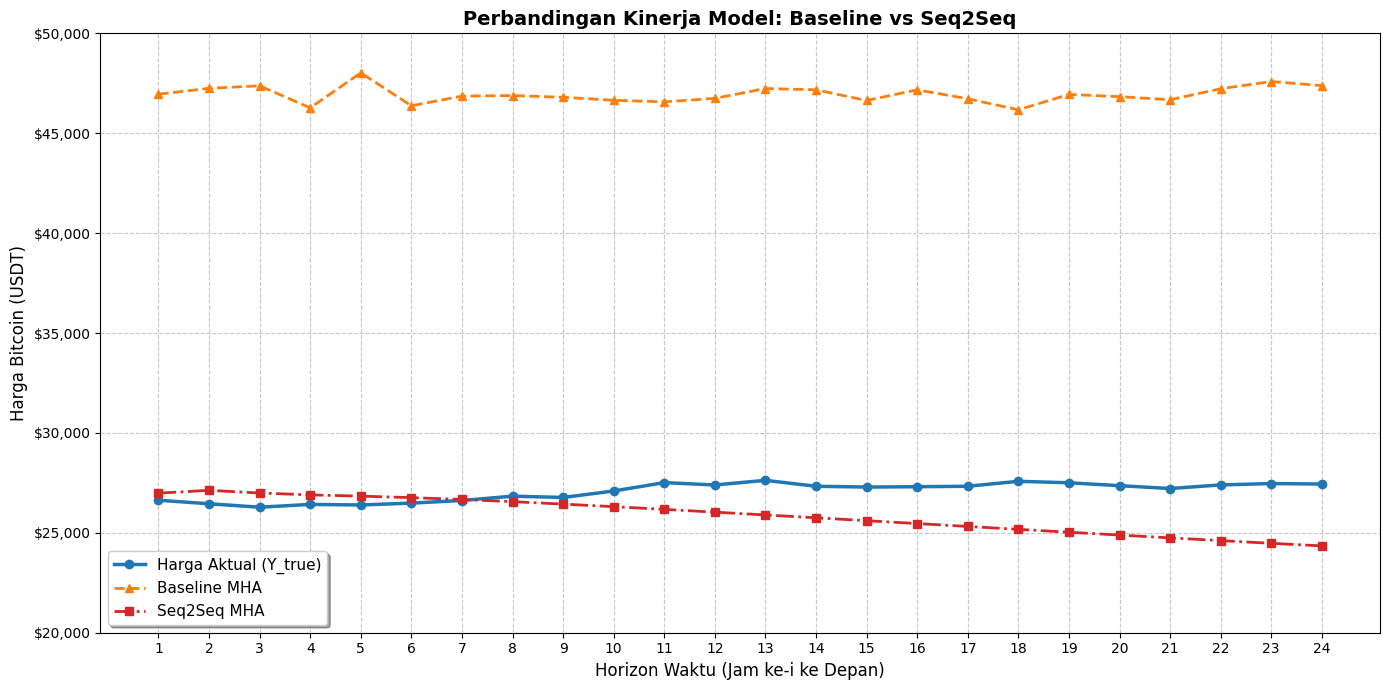

In [37]:
jam_horizon = np.arange(1, LABEL_WIDTH + 1)
plt.figure(figsize=(14, 7))

# Plot Aktual (Biru)
plt.plot(jam_horizon, actual_real_sample, label='Harga Aktual (Y_true)', color='#1f77b4', marker='o', linewidth=2.5)

# Plot Baseline (Oranye)
plt.plot(jam_horizon, baseline_real_sample, label='Baseline MHA', color='#ff7f0e', linestyle='--', marker='^', linewidth=2)

# Plot Seq2Seq (Merah)
plt.plot(jam_horizon, seq2seq_real_sample, label='Seq2Seq MHA', color='#d62728', linestyle='-.', marker='s', linewidth=2)

plt.title('Perbandingan Kinerja Model: Baseline vs Seq2Seq', fontsize=14, fontweight='bold')
plt.xlabel('Horizon Waktu (Jam ke-i ke Depan)', fontsize=12)
plt.ylabel('Harga Bitcoin (USDT)', fontsize=12)
current_values = plt.gca().get_yticks()
plt.gca().set_yticks(current_values)
plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])
plt.xticks(jam_horizon)
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 18. Rincian Tabel Prediksi 24 Jam (Kriteria 3 Basic)
Menampilkan tabel perbandingan detail per jam beserta nilai selisih absolutnya.

In [38]:
df_24_jam = pd.DataFrame({
    'Jam ke': np.arange(1, LABEL_WIDTH + 1),
    'Data Aktual': actual_real_sample,
    'Prediksi Baseline': baseline_real_sample,
    'Selisih Baseline': np.abs(actual_real_sample - baseline_real_sample),
    'Prediksi Seq2Seq': seq2seq_real_sample,
    'Selisih Seq2Seq': np.abs(actual_real_sample - seq2seq_real_sample)
})
print("\n--- Tabel Rincian Prediksi 24 Jam (Sampel #1) ---")
print(df_24_jam.to_string(index=False))


--- Tabel Rincian Prediksi 24 Jam (Sampel #1) ---
 Jam ke  Data Aktual  Prediksi Baseline  Selisih Baseline  Prediksi Seq2Seq  Selisih Seq2Seq
      1 26631.940212       46951.503093      20319.562881      26985.911172       353.970960
      2 26453.890512       47247.514500      20793.623989      27127.190142       673.299630
      3 26283.000647       47375.357561      21092.356914      26993.400711       710.400065
      4 26421.339597       46271.708887      19850.369290      26899.349344       478.009748
      5 26393.980050       48023.133450      21629.153399      26835.800438       441.820388
      6 26487.789505       46375.415302      19887.625798      26761.952683       274.163179
      7 26617.569817       46857.547320      20239.977503      26668.966512        51.396695
      8 26834.869854       46885.761365      20050.891511      26559.460045       275.409809
      9 26769.590492       46798.231886      20028.641395      26438.047180       331.543311
     10 27094.27050

## 19. Penyimpanan Model Akhir (.keras)
Menyimpan arsitektur dan bobot model (Baseline MHA, Encoder, dan Decoder) ke dalam format `.keras` sesuai dengan ketentuan berkas *submission* proyek.

In [39]:
print("[*] Menyimpan model ke dalam format .keras...")

# Karena kita sudah mendefinisikan get_config(), ini akan berhasil 100%
baseline_mha_model.save('model_baseline_LSTM.keras')
encoder.save('model_encoder_Seq2Seq.keras')
decoder.save('model_decoder_Seq2Seq.keras')

print("[*] Seluruh proses selesai. File .keras siap di-submit!")

[*] Menyimpan model ke dalam format .keras...
[*] Seluruh proses selesai. File .keras siap di-submit!
